In [274]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [275]:
def print_multiple_accuracy(run_dirs, labels, title="comparison"):
    """
    run_dirs: пути к папкам
    labels: подписи (["SignMuon", "Adam", "SGD"])
    metric: что выдаем ("train_loss", "test_loss", )
    """
    print(title)

    for run_dir, label in zip(run_dirs, labels):
        run_dir = Path(run_dir)

        with open(run_dir / "metrics.json", "r") as f:
            data = json.load(f)

        # train_acc = data["history"]["train_acc"]
        test_acc = data["history"]["test_acc"]


        print(label)
        # print("train_acc (finish):", train_acc[-1])
        print("test_acc (finish): ", test_acc[-1])
        print('\n')

In [276]:
def plot_multiple_histories(run_dirs, labels, metric="train_loss", title="comparison"):
    """
    run_dirs: пути к папкам
    labels: подписи (["SignMuon", "Adam", "SGD", ...])
    metric: что рисуем ("train_loss", "test_loss", ...)
    """

    plt.figure(figsize=(12, 8))

    markers = ["o", "s", "^", "D", "v", "x", "*"] 

    for i, (run_dir, label) in enumerate(zip(run_dirs, labels)):
        run_dir = Path(run_dir)

        with open(run_dir / "metrics.json", "r") as f:
            data = json.load(f)

        history = data["history"]
        values = history[metric]

        epochs = np.arange(1, len(values) + 1)

        history = data["history"]
        values = np.array(history[metric])

        # Находим индексы, где значение меняется
        # (или можно просто взять каждый 100-й элемент, если вы точно знаете шаг)
        change_indices = [0]  # начинаем с первого элемента
        for idx in range(1, len(values)):
            if values[idx] != values[idx - 1]:  # значение изменилось
                change_indices.append(idx)
        
        # Берём только изменённые значения
        changed_values = values[change_indices]
        changed_epochs = np.array(change_indices) + 1  # +1 если epochs с 1, иначе оставить как есть
        
        plt.plot(
            changed_epochs, 
            changed_values, 
        # plt.plot(
        #     epochs, 
        #     values, 
            label=label,
            marker=markers[i % len(markers)],
            markersize=6, 
            markevery=len(changed_values)//4,
        )

    plt.xlabel("Rounds", fontsize=14)
    plt.ylabel(metric, fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    #plt.title(title)
    plt.grid(True)
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.show()

#  CIFAR10

### Обучение клиентов $\in [1, 3, 5, 7, 9]$ с SignMuon

In [277]:
print_multiple_accuracy(
    run_dirs=[
        "saves_federated/correct_moment/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c1_s1",
        "saves_federated/correct_moment/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c3_s1",
        "saves_federated/correct_moment/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c5_s1",
        "saves_federated/correct_moment/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c7_s1",
        "saves_federated/correct_moment/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c9_s1",
    ],
    labels=[
        "signmuon_cl_homo_cnn2_r2000_c1_s1",
        "signmuon_cl_homo_cnn2_r2000_c3_s1",
        "signmuon_cl_homo_cnn2_r2000_c5_s1",
        "signmuon_cl_homo_cnn2_r2000_c7_s1",
        "signmuon_cl_homo_cnn2_r2000_c9_s1",
    ],
    title="CIFAR10 Loss",
)

CIFAR10 Loss
signmuon_cl_homo_cnn2_r2000_c1_s1
test_acc (finish):  73.28


signmuon_cl_homo_cnn2_r2000_c3_s1
test_acc (finish):  79.27


signmuon_cl_homo_cnn2_r2000_c5_s1
test_acc (finish):  81.01


signmuon_cl_homo_cnn2_r2000_c7_s1
test_acc (finish):  82.85


signmuon_cl_homo_cnn2_r2000_c9_s1
test_acc (finish):  82.88




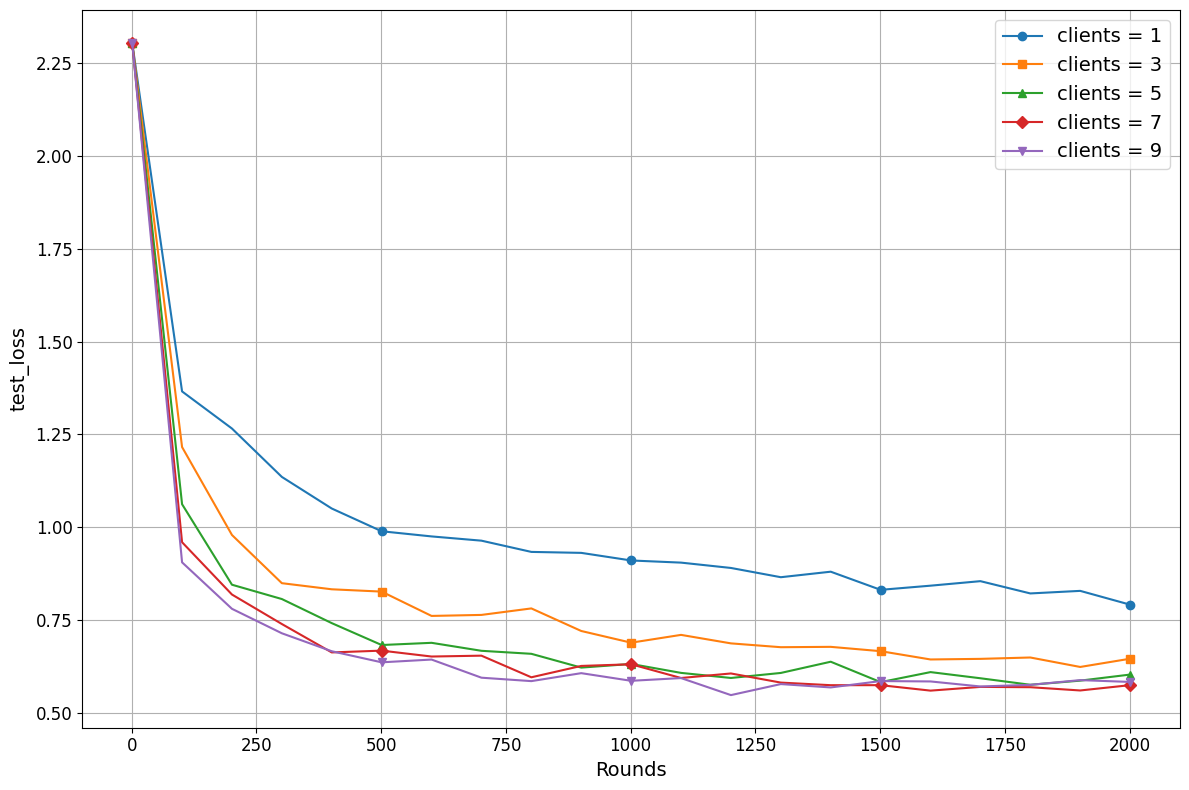

In [278]:
plot_multiple_histories(
    run_dirs=[
        "saves_federated/correct_moment/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c1_s1",
        "saves_federated/correct_moment/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c3_s1",
        "saves_federated/correct_moment/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c5_s1",
        "saves_federated/correct_moment/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c7_s1",
        "saves_federated/correct_moment/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c9_s1",
    ],
    labels=[
        "clients = 1",
        "clients = 3" ,
        "clients = 5",
        "clients = 7",
        "clients = 9"
    ],
    metric="test_loss",
    title="CIFAR10 test loss",
)

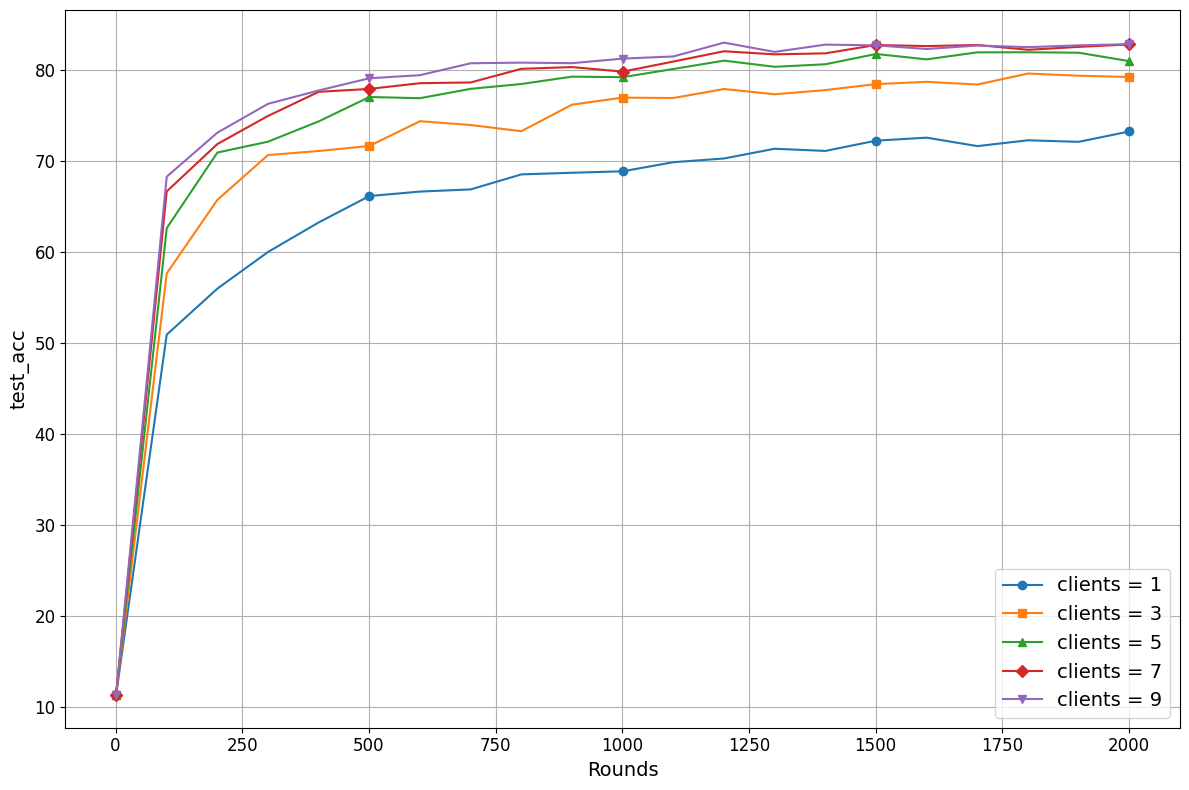

In [279]:
plot_multiple_histories(
    run_dirs=[
        "saves_federated/correct_moment/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c1_s1",
        "saves_federated/correct_moment/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c3_s1",
        "saves_federated/correct_moment/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c5_s1",
        "saves_federated/correct_moment/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c7_s1",
        "saves_federated/correct_moment/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c9_s1",
    ],
    labels=[
        "clients = 1",
        "clients = 3" ,
        "clients = 5",
        "clients = 7",
        "clients = 9"
    ],
    metric="test_acc",
    title="CIFAR10 test accuracy",
)

### Обучение 3 клиентов c шагом 1 с разными алгоритмами

In [280]:
print_multiple_accuracy(
    run_dirs=[
        "saves_federated/correct_moment/fed_cifar10_adam_homo_cnn2_r2000_c3_s1",
        "saves_federated/correct_moment/fed_cifar10_muon_homo_cnn2_r2000_c3_s1",
        "saves_federated/correct_moment/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c3_s1",
        # "saves_federated/correct_moment/fed_cifar10_sgd_homo_cnn2_r2000_c3_s1",
        "saves_federated/correct_moment/fed_cifar10_signsgd_homo_cnn2_r2000_c3_s1",
    ],
    labels=[
        "Adam",
        "Muon",
        "SignMuon",
        "SignSGD",
    ],
    title="CIFAR10 Loss",
)

CIFAR10 Loss
Adam
test_acc (finish):  70.83


Muon
test_acc (finish):  80.12


SignMuon
test_acc (finish):  79.27


SignSGD
test_acc (finish):  65.96




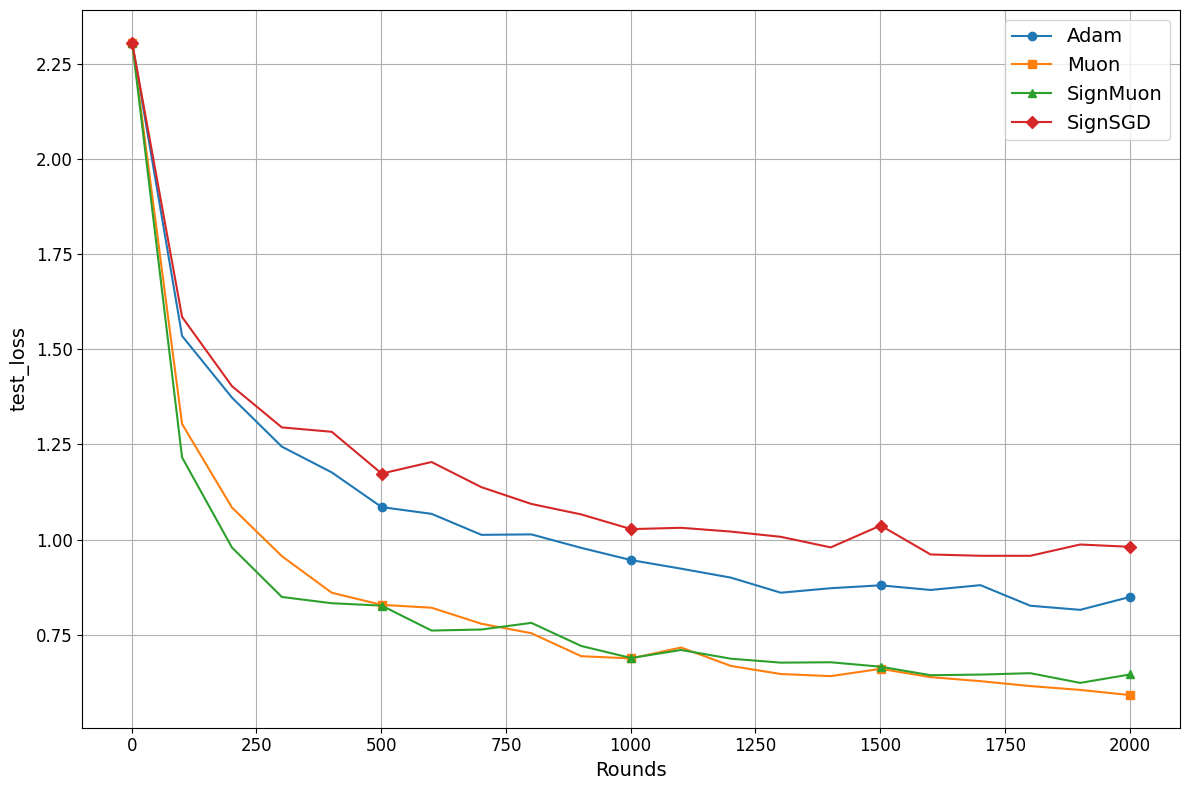

In [281]:
plot_multiple_histories(
    run_dirs=[
        "saves_federated/correct_moment/fed_cifar10_adam_homo_cnn2_r2000_c3_s1",
        "saves_federated/correct_moment/fed_cifar10_muon_homo_cnn2_r2000_c3_s1",
        "saves_federated/correct_moment/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c3_s1",
        # "saves_federated/correct_moment/fed_cifar10_sgd_homo_cnn2_r2000_c3_s1",
        "saves_federated/correct_moment/fed_cifar10_signsgd_homo_cnn2_r2000_c3_s1",
    ],
    labels=[
        "Adam",
        "Muon",
        "SignMuon",
        "SignSGD",
    ],
    metric="test_loss",
    title="CIFAR10 test loss",
)

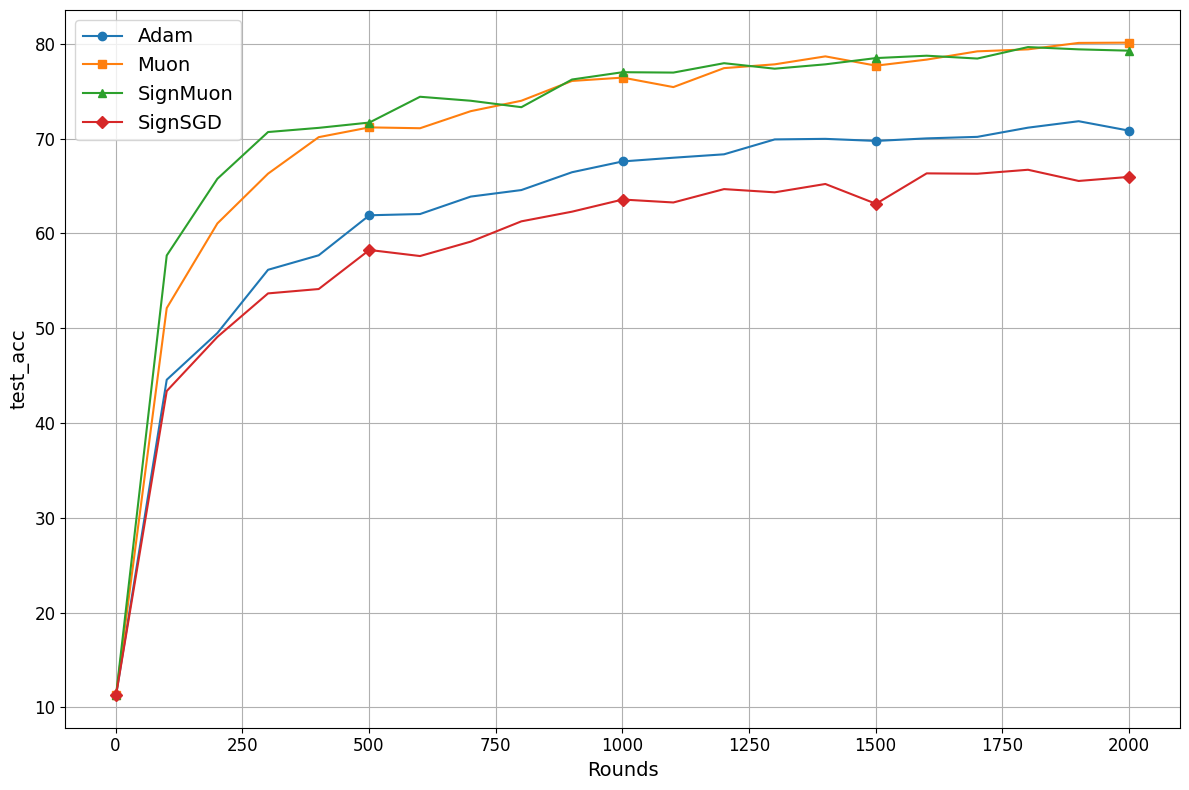

In [282]:
plot_multiple_histories(
    run_dirs=[
        "saves_federated/correct_moment/fed_cifar10_adam_homo_cnn2_r2000_c3_s1",
        "saves_federated/correct_moment/fed_cifar10_muon_homo_cnn2_r2000_c3_s1",
        "saves_federated/correct_moment/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c3_s1",
        # "saves_federated/correct_moment/fed_cifar10_sgd_homo_cnn2_r2000_c3_s1",
        "saves_federated/correct_moment/fed_cifar10_signsgd_homo_cnn2_r2000_c3_s1",
    ],
    labels=[
        "Adam",
        "Muon",
        "SignMuon",
        "SignSGD",
    ],
    metric="test_acc",
    title="CIFAR10 test accuracy",
)

### Обучение 3 клиентов c шагом 1 с разными алгоритмами (SGD, EF)

In [283]:
print_multiple_accuracy(
    run_dirs=[
        "saves_federated/correct_moment/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c3_s1",
        "saves_federated/correct_moment/fed_cifar10_sgd_homo_cnn2_r2000_c3_s1",
        "saves_federated/correct_moment/fed_cifar10_signmuon_ef_homo_cnn2_r2000_c3_s1",
    ],
    labels=[
        "signmuon_cl_homo_cnn2_r2000_c3_st1",
        "sgd_homo_cnn2_r2000_c3_st1",
        "signmuon_ef_homo_cnn2_r2000_c3_st1",
    ],
    title="CIFAR10 Loss",
)

CIFAR10 Loss
signmuon_cl_homo_cnn2_r2000_c3_st1
test_acc (finish):  79.27


sgd_homo_cnn2_r2000_c3_st1
test_acc (finish):  52.88


signmuon_ef_homo_cnn2_r2000_c3_st1
test_acc (finish):  67.04




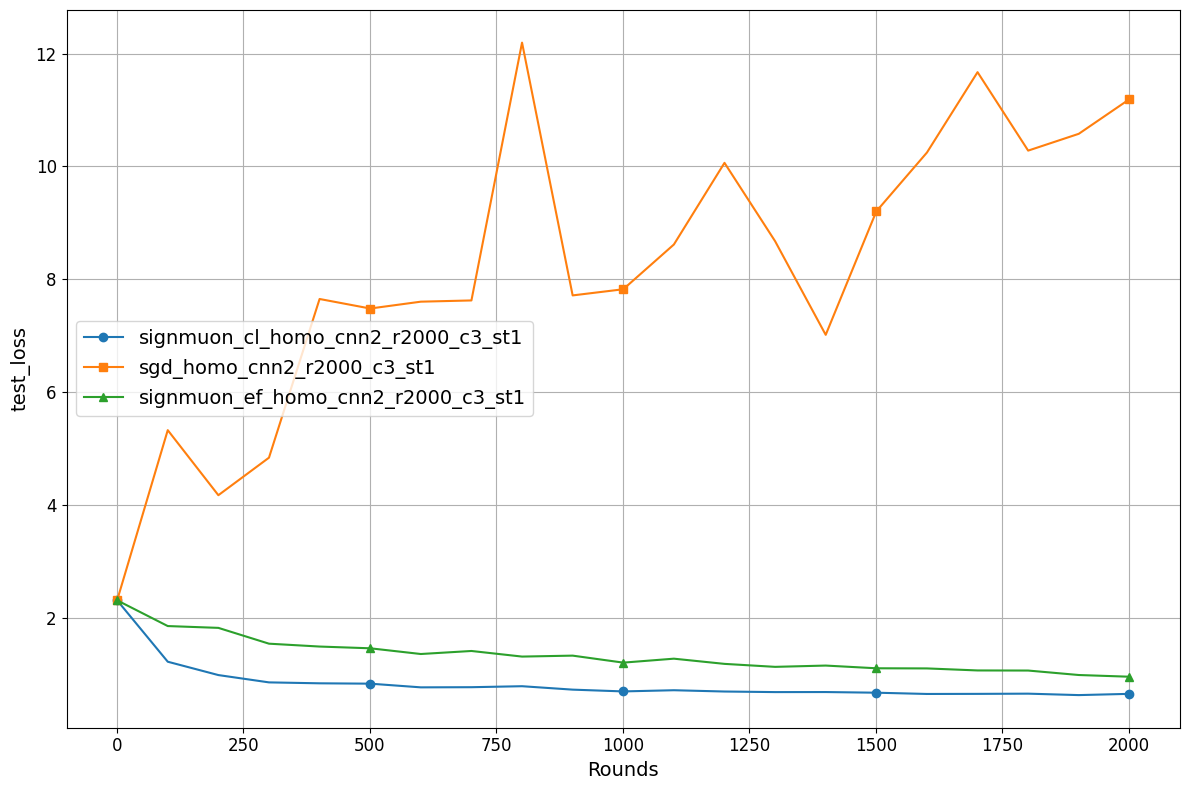

In [284]:
plot_multiple_histories(
    run_dirs=[
        "saves_federated/correct_moment/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c3_s1",
        "saves_federated/correct_moment/fed_cifar10_sgd_homo_cnn2_r2000_c3_s1",
        "saves_federated/correct_moment/fed_cifar10_signmuon_ef_homo_cnn2_r2000_c3_s1",
    ],
    labels=[
        "signmuon_cl_homo_cnn2_r2000_c3_st1",
        "sgd_homo_cnn2_r2000_c3_st1",
        "signmuon_ef_homo_cnn2_r2000_c3_st1",
    ],
    metric="test_loss",
    title="CIFAR10 test loss",
)

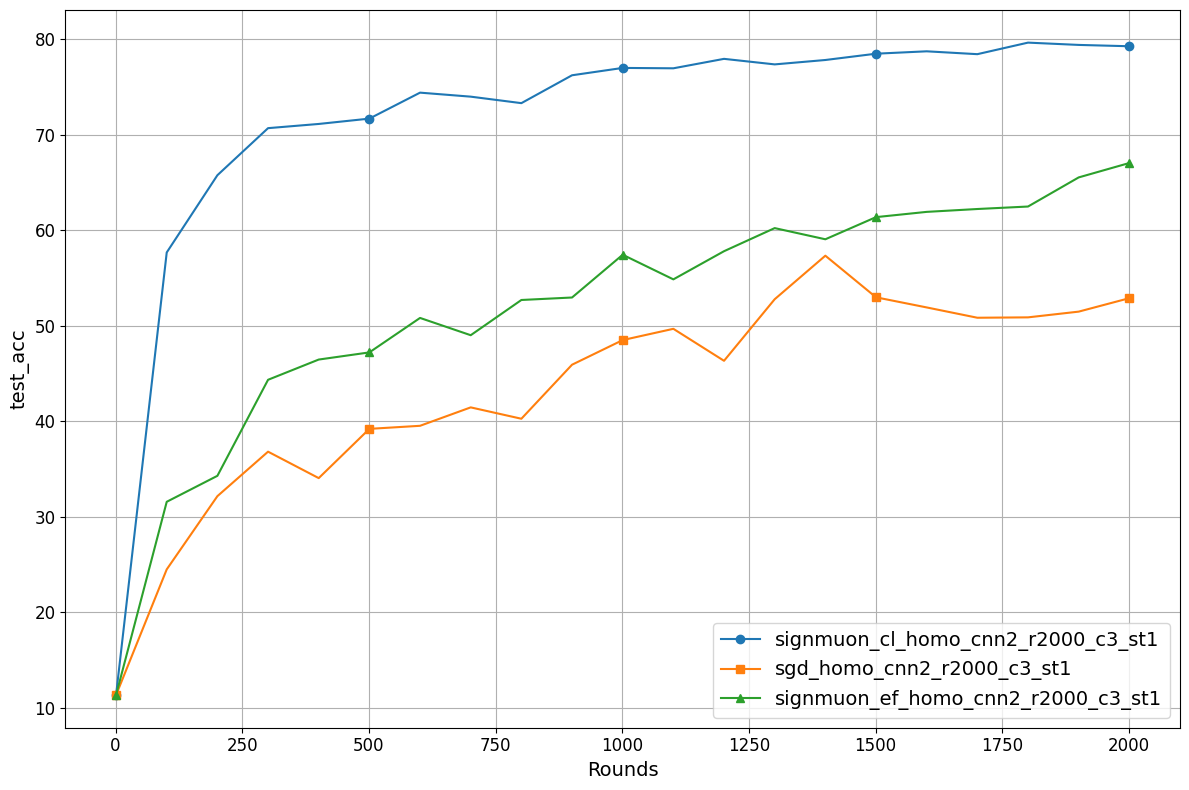

In [285]:
plot_multiple_histories(
    run_dirs=[
        "saves_federated/correct_moment/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c3_s1",
        "saves_federated/correct_moment/fed_cifar10_sgd_homo_cnn2_r2000_c3_s1",
        "saves_federated/correct_moment/fed_cifar10_signmuon_ef_homo_cnn2_r2000_c3_s1",
    ],
    labels=[
        "signmuon_cl_homo_cnn2_r2000_c3_st1",
        "sgd_homo_cnn2_r2000_c3_st1",
        "signmuon_ef_homo_cnn2_r2000_c3_st1",
    ],
    metric="test_acc",
    title="CIFAR10 test accuracy",
)

### Обучение 10 клиентов шагом 3 с разными алгоритмами

In [286]:
print_multiple_accuracy(
    run_dirs=[
        "saves_federated/correct_moment/fed_cifar10_adam_homo_cnn2_r2000_c10_s3",
        "saves_federated/correct_moment/fed_cifar10_muon_homo_cnn2_r2000_c10_s3",
        "saves_federated/correct_moment/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c10_s3",
        #"saves_federated/correct_moment/fed_cifar10_sgd_homo_cnn2_r2000_c10_s3",
        "saves_federated/correct_moment/fed_cifar10_signsgd_homo_cnn2_r2000_c10_s3",
    ],
    labels=[
        "Adam",
        "Muon",
        "SignMuon",
        "SignSGD",
    ],
    title="CIFAR10 Loss",
)

CIFAR10 Loss
Adam
test_acc (finish):  78.36


Muon
test_acc (finish):  84.63000000000001


SignMuon
test_acc (finish):  84.93


SignSGD
test_acc (finish):  78.97999999999999




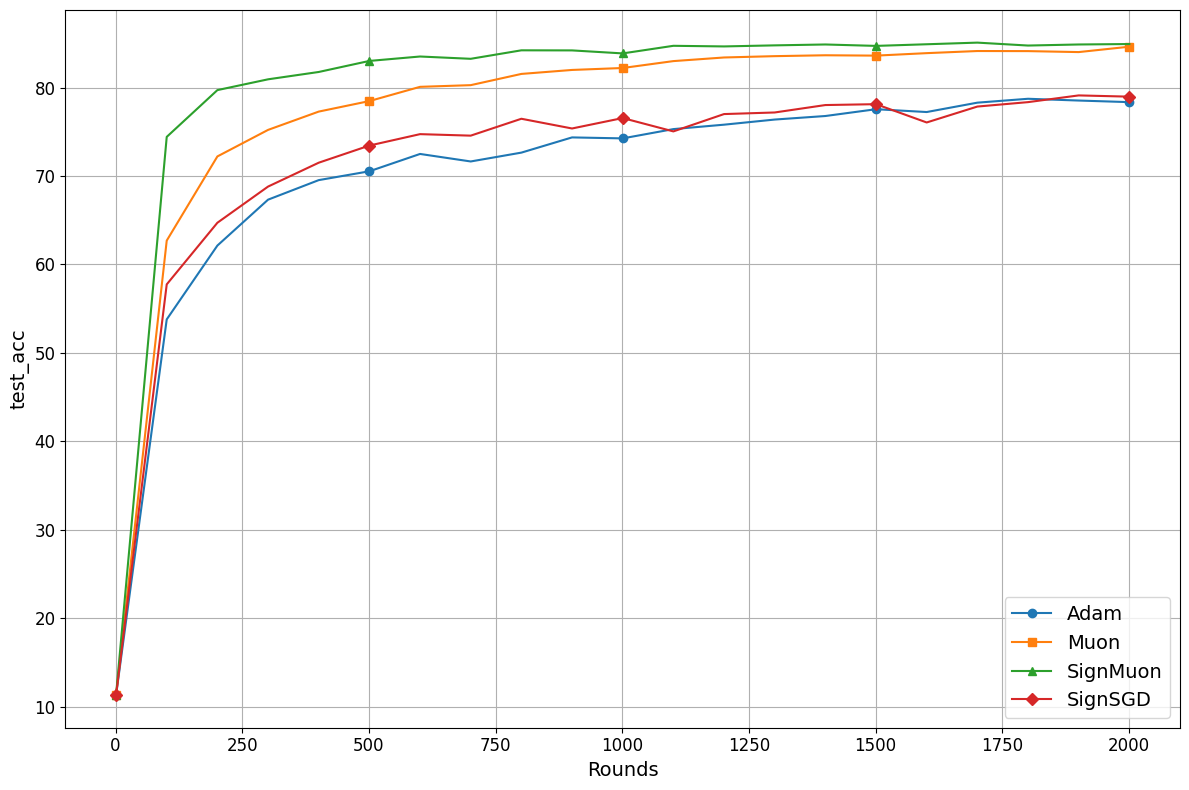

In [287]:
plot_multiple_histories(
    run_dirs=[
        "saves_federated/correct_moment/fed_cifar10_adam_homo_cnn2_r2000_c10_s3",
        "saves_federated/correct_moment/fed_cifar10_muon_homo_cnn2_r2000_c10_s3",
        "saves_federated/correct_moment/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c10_s3",
        #"saves_federated/correct_moment/fed_cifar10_sgd_homo_cnn2_r2000_c10_s3",
        "saves_federated/correct_moment/fed_cifar10_signsgd_homo_cnn2_r2000_c10_s3",
    ],
    labels=[
        "Adam",
        "Muon",
        "SignMuon",
        "SignSGD",
    ],
    metric="test_acc",
    title="CIFAR10 test accuracy",
)

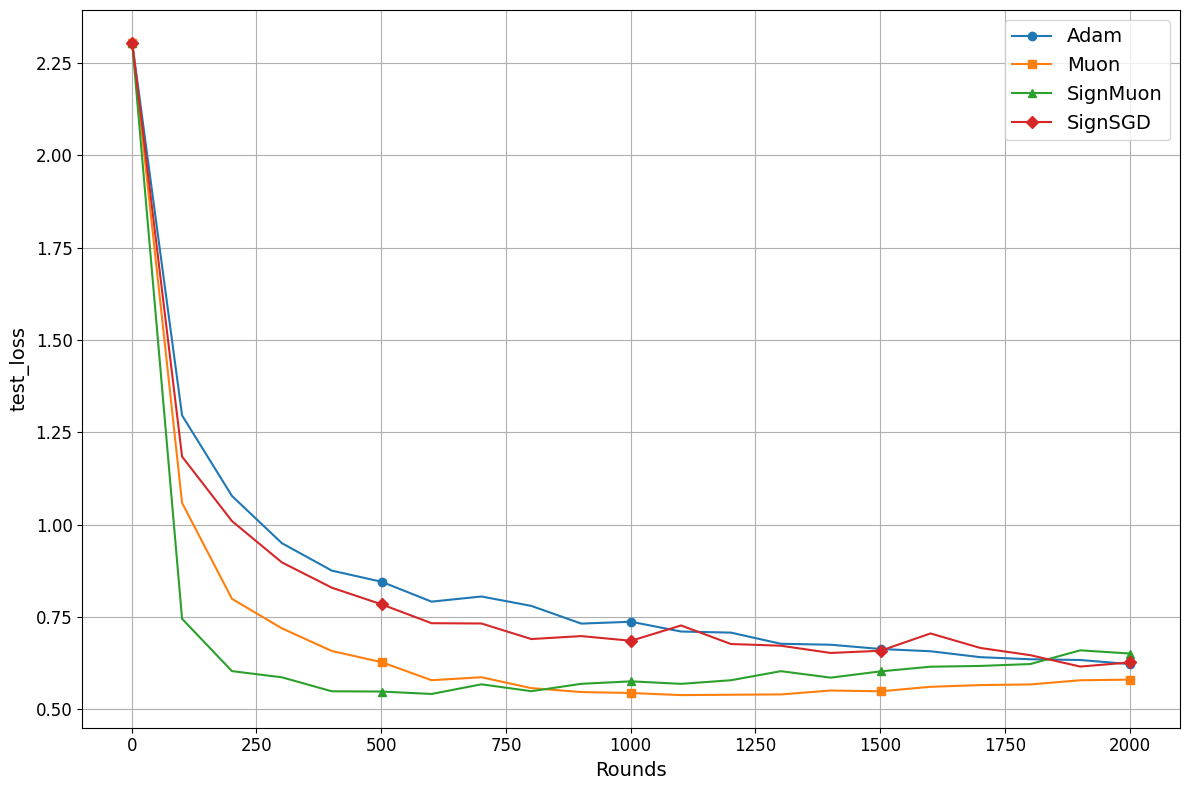

In [288]:
plot_multiple_histories(
    run_dirs=[
        "saves_federated/correct_moment/fed_cifar10_adam_homo_cnn2_r2000_c10_s3",
        "saves_federated/correct_moment/fed_cifar10_muon_homo_cnn2_r2000_c10_s3",
        "saves_federated/correct_moment/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c10_s3",
        #"saves_federated/correct_moment/fed_cifar10_sgd_homo_cnn2_r2000_c10_s3",
        "saves_federated/correct_moment/fed_cifar10_signsgd_homo_cnn2_r2000_c10_s3",
    ],
    labels=[
        "Adam",
        "Muon",
        "SignMuon",
        "SignSGD",
    ],
    metric="test_loss",
    title="CIFAR10 test loss",
)

### Обучение 10 клиентов c шагом 3 с разными алгоритмами (SGD, EF)

In [289]:
print_multiple_accuracy(
    run_dirs=[
        "saves_federated/correct_moment/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c10_s3",
        "saves_federated/correct_moment/fed_cifar10_sgd_homo_cnn2_r2000_c10_s3",
        "saves_federated/correct_moment/fed_cifar10_signmuon_ef_homo_cnn2_r2000_c10_s3",
    ],
    labels=[
        "signmuon_cl_homo_cnn2_r2000_c3_st1",
        "sgd_homo_cnn2_r2000_c3_st1",
        "signmuon_ef_homo_cnn2_r2000_c3_st1",
    ],
    title="CIFAR10 Loss",
)

CIFAR10 Loss
signmuon_cl_homo_cnn2_r2000_c3_st1
test_acc (finish):  84.93


sgd_homo_cnn2_r2000_c3_st1
test_acc (finish):  55.96


signmuon_ef_homo_cnn2_r2000_c3_st1
test_acc (finish):  70.43




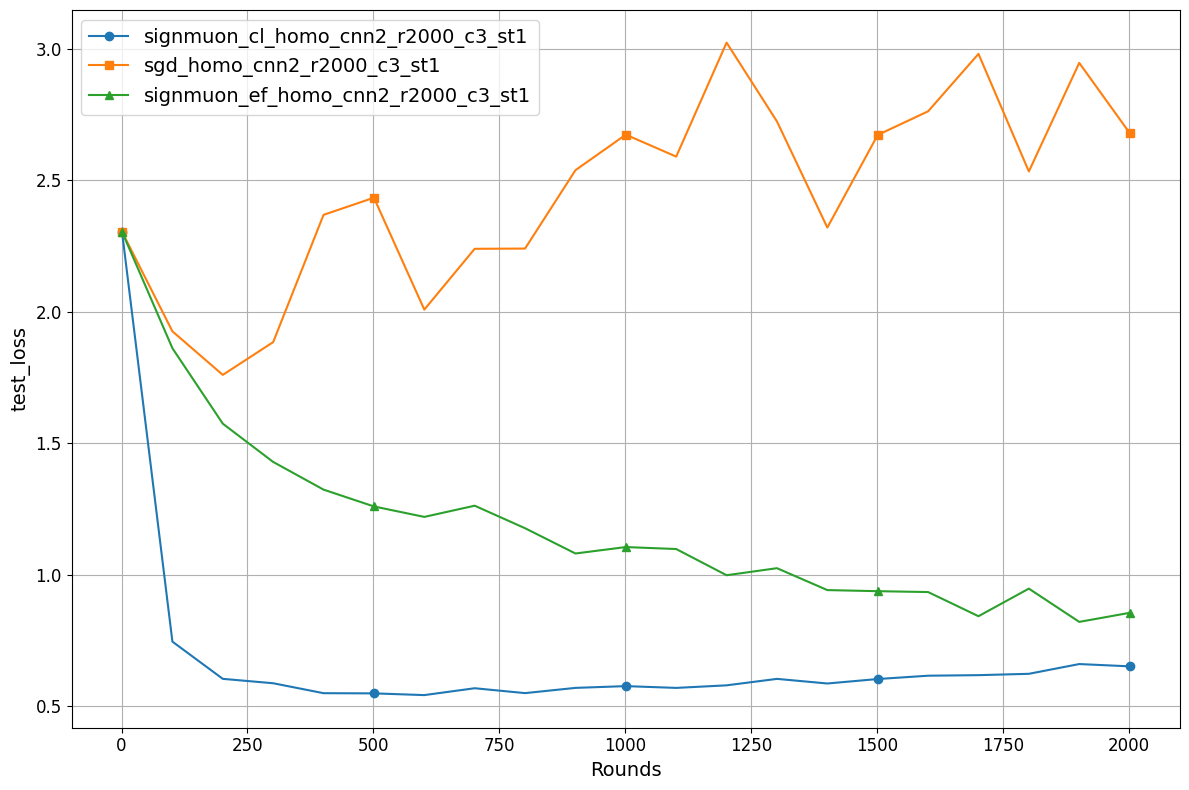

In [290]:
plot_multiple_histories(
    run_dirs=[
        "saves_federated/correct_moment/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c10_s3",
        "saves_federated/correct_moment/fed_cifar10_sgd_homo_cnn2_r2000_c10_s3",
        "saves_federated/correct_moment/fed_cifar10_signmuon_ef_homo_cnn2_r2000_c10_s3",
    ],
    labels=[
        "signmuon_cl_homo_cnn2_r2000_c3_st1",
        "sgd_homo_cnn2_r2000_c3_st1",
        "signmuon_ef_homo_cnn2_r2000_c3_st1",
    ],
    metric="test_loss",
    title="CIFAR10 test loss",
)

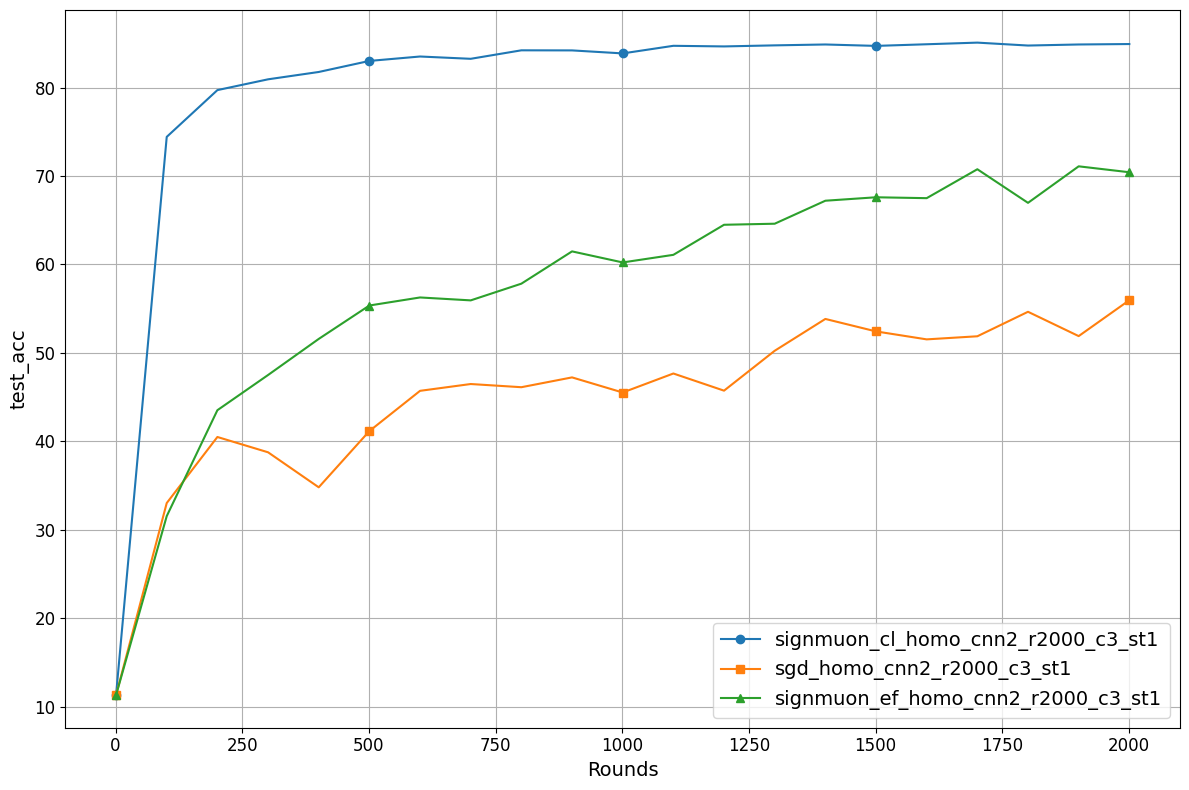

In [291]:
plot_multiple_histories(
    run_dirs=[
        "saves_federated/correct_moment/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c10_s3",
        "saves_federated/correct_moment/fed_cifar10_sgd_homo_cnn2_r2000_c10_s3",
        "saves_federated/correct_moment/fed_cifar10_signmuon_ef_homo_cnn2_r2000_c10_s3",
    ],
    labels=[
        "signmuon_cl_homo_cnn2_r2000_c3_st1",
        "sgd_homo_cnn2_r2000_c3_st1",
        "signmuon_ef_homo_cnn2_r2000_c3_st1",
    ],
    metric="test_acc",
    title="CIFAR10 test loss",
)